# 01 — Análisis Exploratorio de Datos (EDA)

**Objetivo:** Comprender la estructura del dataset de RRHH generado por el pipeline Kedro,  
identificar patrones relevantes y caracterizar las variables objetivo antes del modelado.

**Dataset:** `master_table.csv` — 3.000 empleados, 33 variables, integración de 4 fuentes CSV.

**Variables objetivo:**
- `y_binario`: Fuga del empleado (clasificación binaria)
- `y_multiclase`: Performance Score (4 categorías)
- `Current Employee Rating`: Calificación numérica (regresión)

In [5]:
import sys, os
import warnings
warnings.filterwarnings("ignore")

# Detecta la raíz del proyecto automáticamente desde la ubicación del notebook
ROOT = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))

# Verificación de seguridad
if not os.path.exists(os.path.join(ROOT, "data", "03_primary", "master_table.csv")):
    # Fallback: subir niveles hasta encontrar la raíz
    current = os.getcwd()
    for _ in range(5):
        if os.path.exists(os.path.join(current, "data", "03_primary", "master_table.csv")):
            ROOT = current
            break
        current = os.path.dirname(current)

os.chdir(ROOT)
sys.path.insert(0, os.path.join(ROOT, "src"))

from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("data/03_primary/master_table.csv")
print(f"Directorio actual: {os.getcwd()}")
print(f"Shape: {df.shape}")
df.head(3)

Directorio actual: C:\Users\BzTTY\Downloads\Parcial 2 Ciencia Datos\Parcial2-CG\ev-parcial2-gonzalez
Shape: (3000, 33)


,EmpID,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,EmployeeStatus,...,Performance Score,Current Employee Rating,Survey Date,Engagement Score,Satisfaction Score,Work-Life Balance Score,Total Training Cost,Seniority_Years,Normalized_Training_Cost,Gender_Male
0,3427,Uriah,Bridges,2019-09-20,Desconocido,Production Technician I,Peter Oneill,Uriah.Bridges@Bilearner.Com,Ccdr,Active,...,Fully Meets,4.0,14-01-2023,1,2,3,606.11,6.661191,0.562344,False
1,3428,Paula,Small,2023-02-11,Desconocido,Production Technician I,Renee Mccormick,Paula.Small@Bilearner.Com,Ew,Active,...,Fully Meets,3.0,09-09-2022,2,1,5,673.02,3.266256,0.636694,True
2,3429,Edward,Buck,2018-12-10,Desconocido,Area Sales Manager,Crystal Walker,Edward.Buck@Bilearner.Com,Pl,Active,...,Fully Meets,4.0,27-05-2023,1,2,1,413.28,7.438741,0.348072,True


## 1. Inspección General del Dataset

In [3]:
print("=" * 50)
print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
print(f"Duplicados: {df.duplicated().sum()}")
print("=" * 50)

nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({"Nulos": nulos, "% Faltante": nulos_pct})
print("\nColumnas con valores nulos:")
display(resumen_nulos[resumen_nulos["Nulos"] > 0])

print("\nTipos de datos:")
display(df.dtypes.value_counts().rename("Columnas").to_frame())

Filas: 3,000  |  Columnas: 33
Duplicados: 0

Columnas con valores nulos:


,Nulos,% Faltante



Tipos de datos:


,Columnas
object,23
int64,5
float64,4
bool,1


> **Conclusión:** El dataset no presenta duplicados. Los nulos, si existen, se concentran en variables secundarias y son manejados por la etapa de preprocesamiento del pipeline Kedro mediante imputación por mediana (numéricas) y moda (categóricas).

## 2. Análisis de la Variable Objetivo: Fuga de Empleados

Este es el análisis más crítico del EDA. El problema de clasificación binaria tiene una distribución  
muy desbalanceada que determinará toda la estrategia de modelado.

In [11]:
from ev_parcial2_gonzalez.modeling.train import prepare_targets

_, y_bin, y_mul = prepare_targets(df)

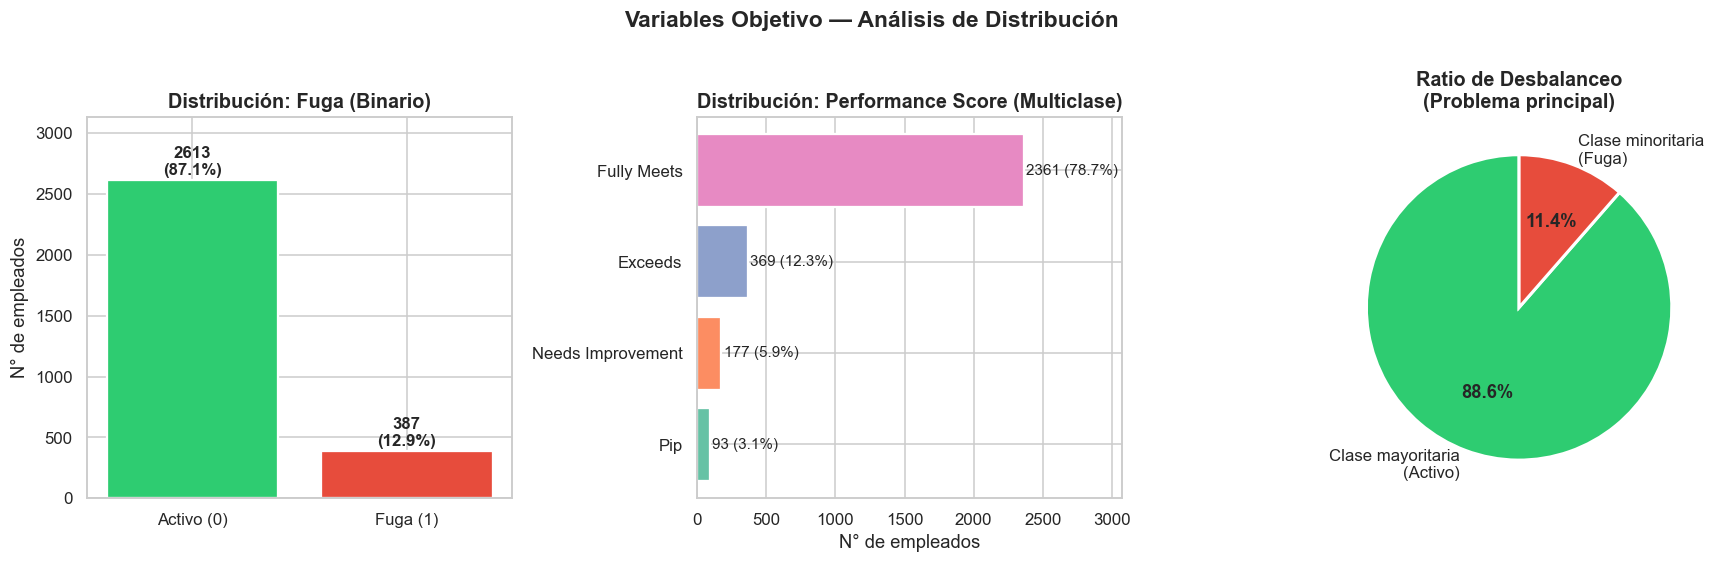


Ratio de desbalanceo: 6.8:1 (clase mayoritaria vs minoritaria)
Implicación: sin corrección, un modelo que predice siempre 'Activo' obtiene 87.1% accuracy.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Target binario ---
conteo_bin = y_bin.value_counts()
colores_bin = ["#2ecc71", "#e74c3c"]
bars = axes[0].bar(["Activo (0)", "Fuga (1)"], conteo_bin.values,
                   color=colores_bin, edgecolor="white", linewidth=1.5)
for bar, v in zip(bars, conteo_bin.values):
    pct = v / len(y_bin) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f"{v}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_title("Distribución: Fuga (Binario)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("N° de empleados")
axes[0].set_ylim(0, max(conteo_bin.values) * 1.2)

# --- Target multiclase ---
conteo_mul = y_mul.value_counts().sort_values(ascending=True)
colores_mul = sns.color_palette("Set2", len(conteo_mul))
barsh = axes[1].barh(conteo_mul.index, conteo_mul.values,
                     color=colores_mul, edgecolor="white", linewidth=1.5)
for bar, v in zip(barsh, conteo_mul.values):
    pct = v / len(y_mul) * 100
    axes[1].text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
                 f"{v} ({pct:.1f}%)", va="center", fontsize=10)
axes[1].set_title("Distribución: Performance Score (Multiclase)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("N° de empleados")
axes[1].set_xlim(0, max(conteo_mul.values) * 1.3)

# --- Ratio de desbalanceo ---
ratio_datos = [len(y_bin), conteo_bin.min()]
ratio_labels = ["Clase mayoritaria\n(Activo)", "Clase minoritaria\n(Fuga)"]
wedges, texts, autotexts = axes[2].pie(
    ratio_datos, labels=ratio_labels, autopct="%1.1f%%",
    colors=colores_bin, startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight("bold")
axes[2].set_title("Ratio de Desbalanceo\n(Problema principal)", fontsize=13, fontweight="bold")

plt.suptitle("Variables Objetivo — Análisis de Distribución",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
os.makedirs("results/plots", exist_ok=True)
plt.savefig("results/plots/eda_target_distribution.png", bbox_inches="tight")
plt.show()

ratio = conteo_bin.max() / conteo_bin.min()
print(f"\nRatio de desbalanceo: {ratio:.1f}:1 (clase mayoritaria vs minoritaria)")
print(f"Implicación: sin corrección, un modelo que predice siempre 'Activo' obtiene {conteo_bin.max()/len(y_bin)*100:.1f}% accuracy.")

> **Conclusión crítica:** El dataset presenta un desbalanceo severo de ~6.7:1 en la variable de fuga.  
> Un clasificador trivial que predice siempre la clase mayoritaria (Activo) obtendría ~87% de accuracy  
> sin aprender nada útil. Por esto, **accuracy no es una métrica válida** para este problema y se usa  
> **F1-Score (binary)** como métrica principal. El uso de **SMOTE** en el pipeline de entrenamiento es  
> la respuesta técnica directa a este desbalanceo.

## 3. Correlación de Features con la Variable de Fuga

Antes de modelar, identificamos qué variables tienen mayor asociación con la fuga.  
Esto permite anticipar qué features serán más importantes y validar la selección de algoritmos.

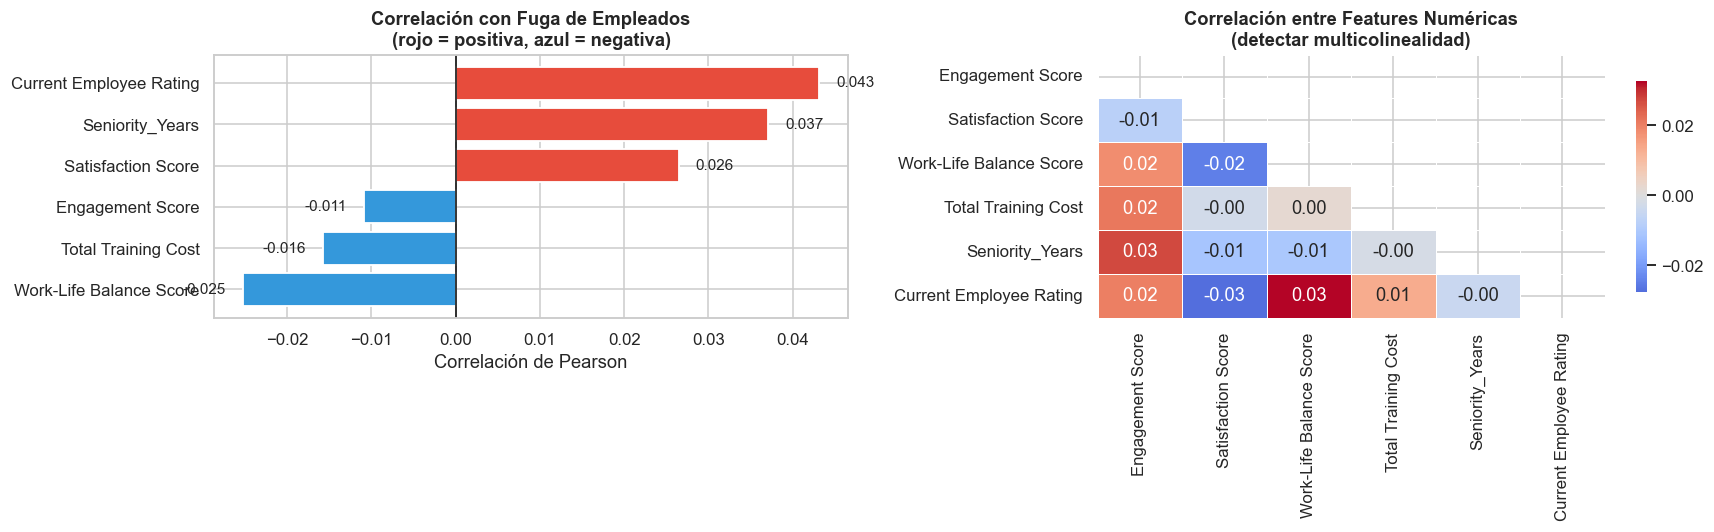

In [10]:
from ev_parcial2_gonzalez.modeling.config import NUMERIC_FEATURES

# Correlación punto-biserial entre features numéricas y target binario
df_corr = df.copy()
df_corr["y_bin"] = y_bin.values

corr_con_fuga = df_corr[NUMERIC_FEATURES + ["y_bin"]].corr()["y_bin"].drop("y_bin").sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Correlación con target ---
colores_corr = ["#e74c3c" if v > 0 else "#3498db" for v in corr_con_fuga.values]
bars = axes[0].barh(corr_con_fuga.index, corr_con_fuga.values,
                    color=colores_corr, edgecolor="white", linewidth=1.2)
axes[0].axvline(0, color="black", linewidth=1)
for bar, v in zip(bars, corr_con_fuga.values):
    axes[0].text(v + (0.002 if v >= 0 else -0.002), bar.get_y() + bar.get_height()/2,
                 f"{v:.3f}", va="center", ha="left" if v >= 0 else "right", fontsize=10)
axes[0].set_title("Correlación con Fuga de Empleados\n(rojo = positiva, azul = negativa)",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Correlación de Pearson")

# --- Heatmap entre todas las features numéricas ---
corr_matrix = df_corr[NUMERIC_FEATURES].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=axes[1],
            linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[1].set_title("Correlación entre Features Numéricas\n(detectar multicolinealidad)",
                  fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("results/plots/eda_correlacion_fuga.png", bbox_inches="tight")
plt.show()

> **Conclusión:** Las correlaciones individuales con la fuga son bajas, lo cual es esperable en datasets  
> de RRHH donde el comportamiento emerge de la combinación de variables. La ausencia de alta multicolinealidad  
> entre features confirma que el PCA encontró poca redundancia (90% de varianza en 6 componentes = 6 features).  
> Esto justifica mantener todas las features numéricas en el pipeline.

## 4. Análisis de Features por Grupo de Fuga

Comparación directa de las distribuciones de features numéricas entre empleados activos y fugados.

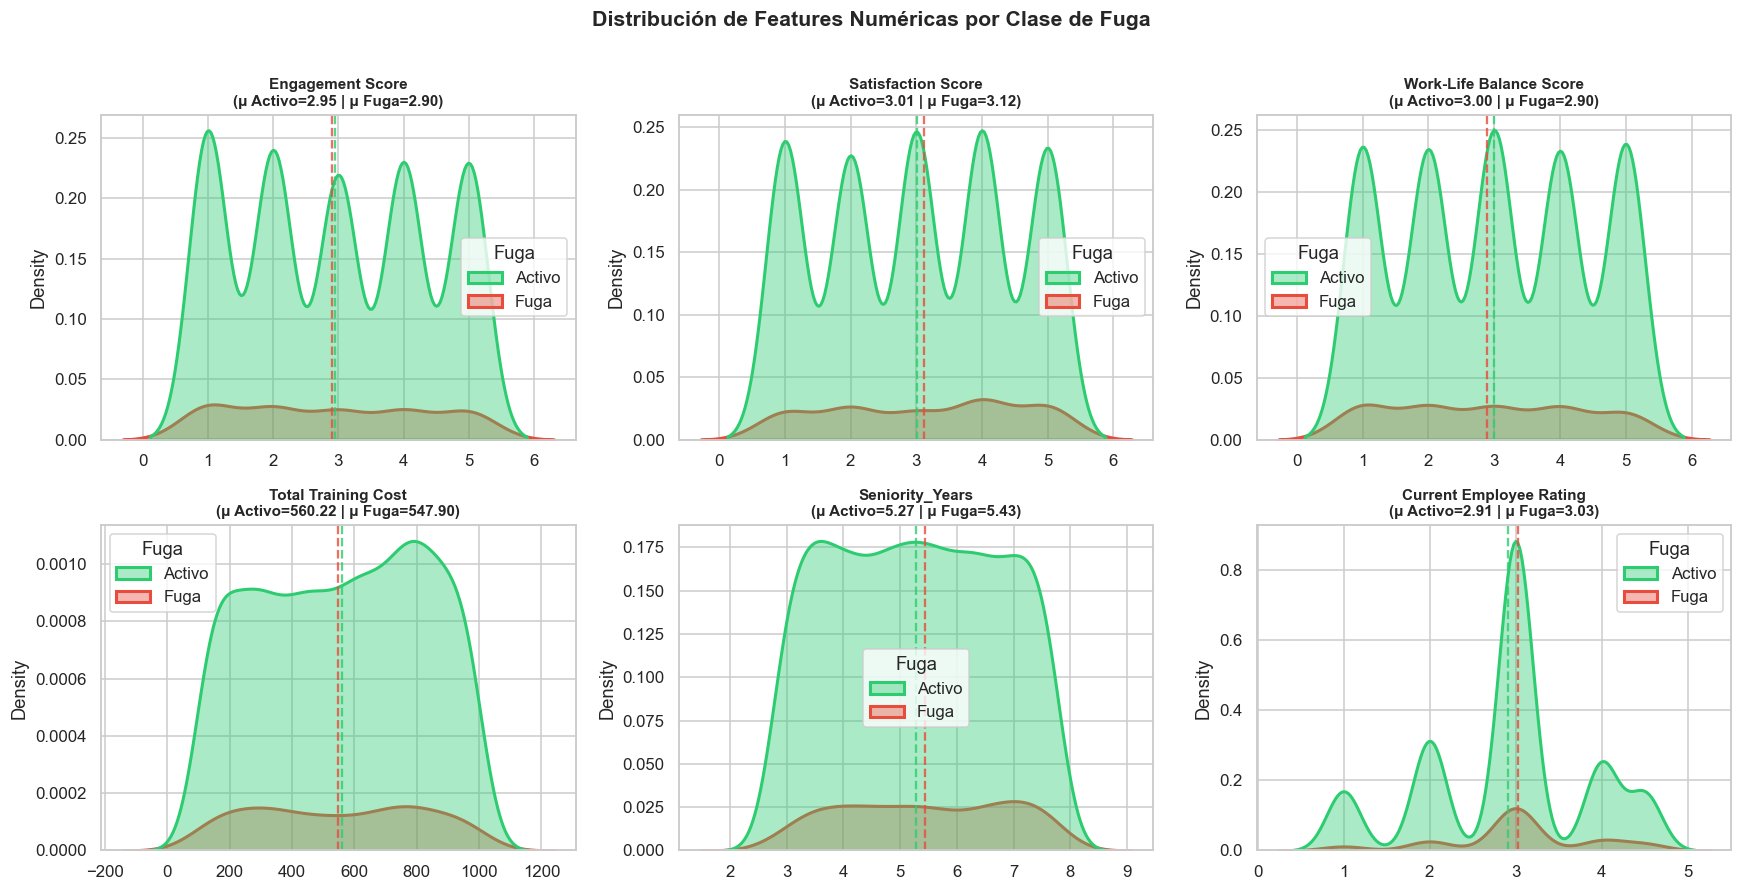

In [7]:
df_plot = df.copy()
df_plot["Fuga"] = y_bin.map({0: "Activo", 1: "Fuga"})

n_features = len(NUMERIC_FEATURES)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(NUMERIC_FEATURES):
    if feat not in df_plot.columns:
        axes[i].set_visible(False)
        continue
    sns.kdeplot(data=df_plot, x=feat, hue="Fuga",
                palette={"Activo": "#2ecc71", "Fuga": "#e74c3c"},
                fill=True, alpha=0.4, ax=axes[i], linewidth=2)
    media_activo = df_plot[df_plot["Fuga"]=="Activo"][feat].mean()
    media_fuga   = df_plot[df_plot["Fuga"]=="Fuga"][feat].mean()
    axes[i].axvline(media_activo, color="#2ecc71", linestyle="--", linewidth=1.5, alpha=0.8)
    axes[i].axvline(media_fuga,   color="#e74c3c", linestyle="--", linewidth=1.5, alpha=0.8)
    axes[i].set_title(f"{feat}\n(μ Activo={media_activo:.2f} | μ Fuga={media_fuga:.2f})",
                      fontsize=10, fontweight="bold")
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución de Features Numéricas por Clase de Fuga",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("results/plots/eda_features_por_fuga.png", bbox_inches="tight")
plt.show()

> **Conclusión:** Las distribuciones KDE por clase permiten identificar si alguna feature  
> discrimina naturalmente entre empleados activos y fugados. La superposición significativa  
> entre curvas en la mayoría de features explica por qué los modelos lineales tienen dificultades:  
> no existe un umbral simple en ninguna variable individual que separe ambas clases.

## 5. Distribución de Variables Numéricas Clave

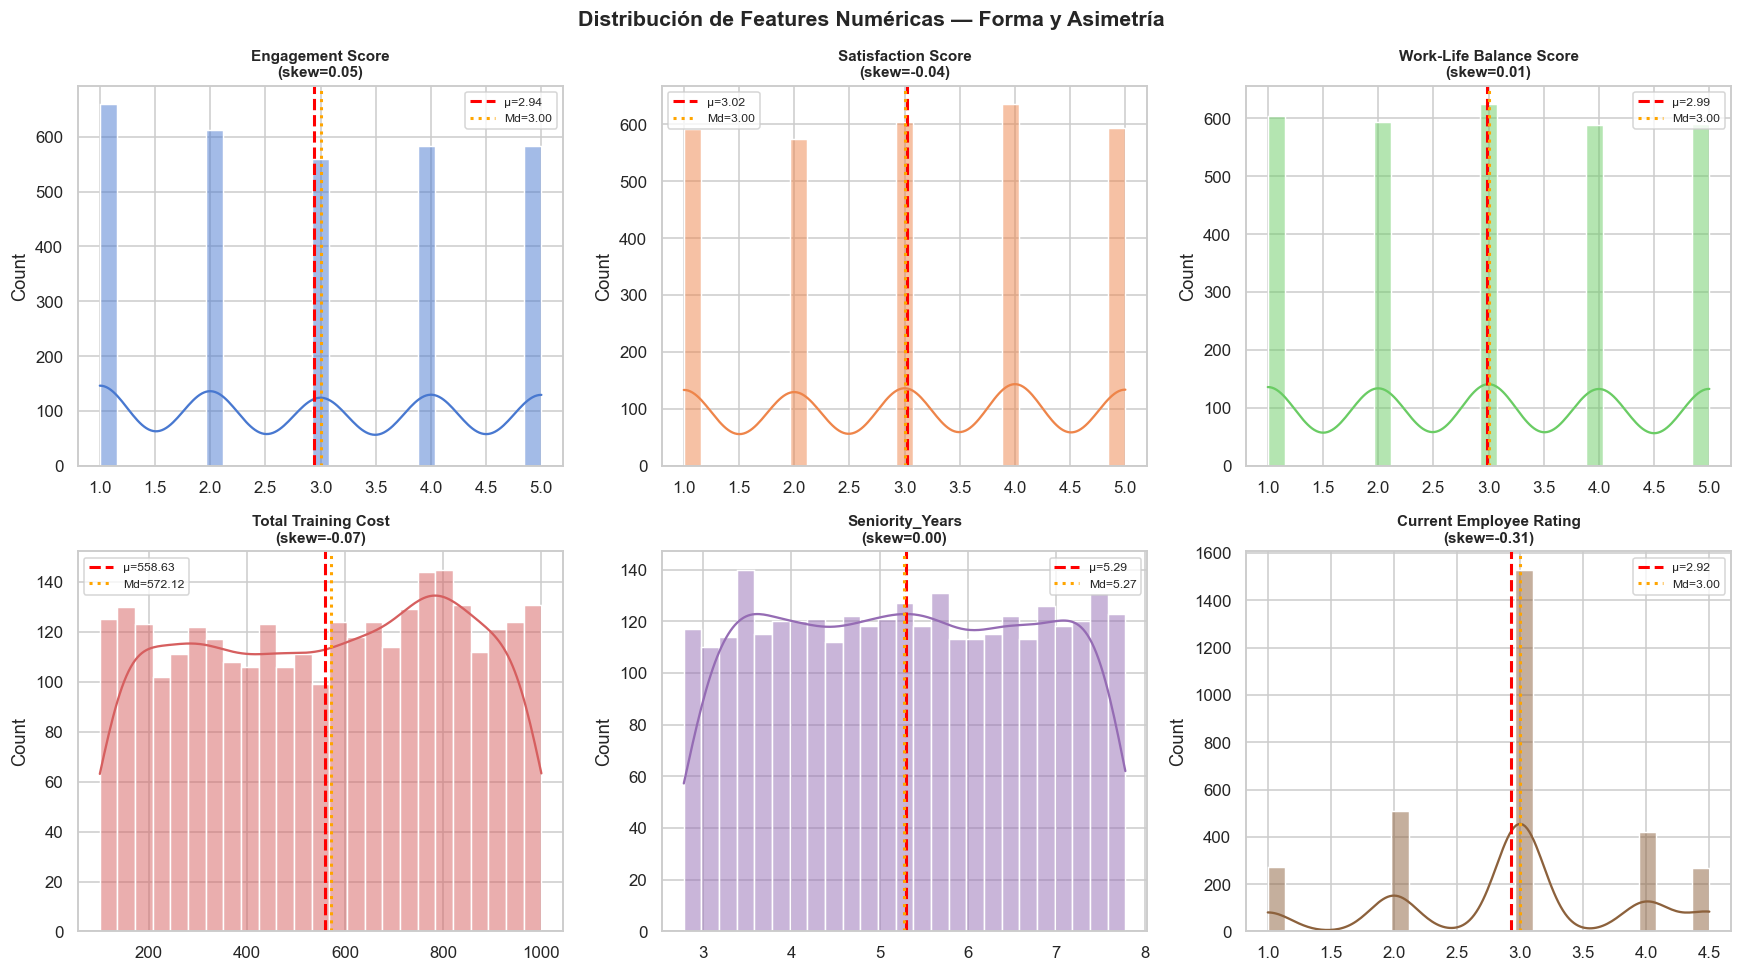

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(NUMERIC_FEATURES):
    if feat not in df.columns:
        axes[i].set_visible(False)
        continue
    data = df[feat].dropna()
    sns.histplot(data, bins=25, kde=True, ax=axes[i],
                 color=sns.color_palette("muted")[i % 6], edgecolor="white")
    axes[i].axvline(data.mean(), color="red", ls="--", lw=2, label=f"μ={data.mean():.2f}")
    axes[i].axvline(data.median(), color="orange", ls=":", lw=2, label=f"Md={data.median():.2f}")
    axes[i].set_title(f"{feat}\n(skew={data.skew():.2f})", fontsize=10, fontweight="bold")
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución de Features Numéricas — Forma y Asimetría",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("results/plots/eda_distribuciones_numericas.png", bbox_inches="tight")
plt.show()

> **Conclusión:** Variables con asimetría positiva alta (como `Total Training Cost`) justifican  
> la imputación por **mediana** en lugar de media, ya que la media es sensible a outliers en  
> distribuciones sesgadas. El `StandardScaler` posterior normaliza la escala para modelos  
> sensibles a la magnitud (SVC, KNN, MLP).

## 6. Análisis de Variables Categóricas Relevantes

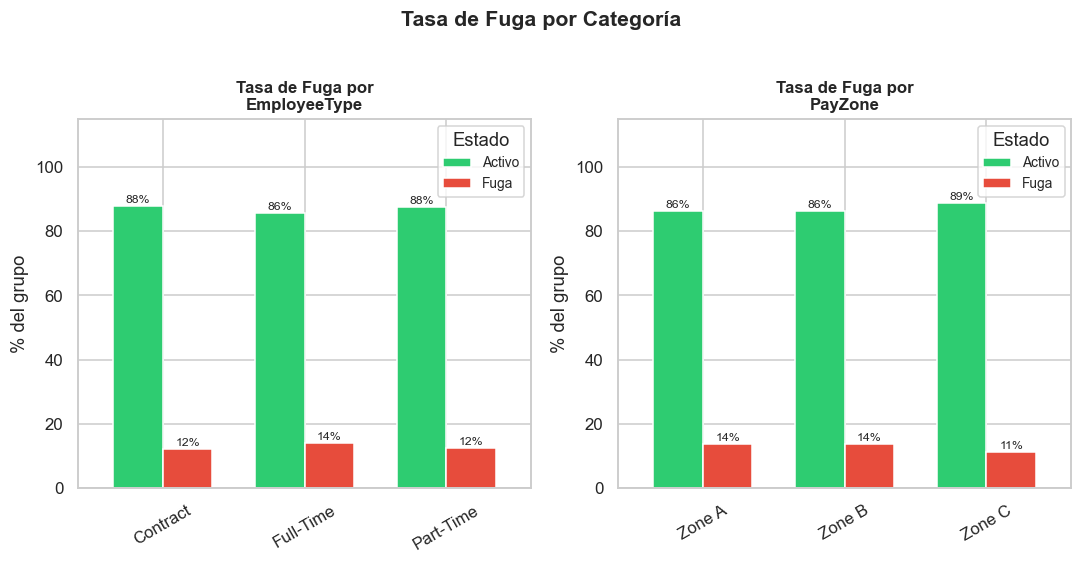

In [9]:
cat_cols_plot = ["Department Type", "EmployeeType", "GenderCode", "PayZone"]
cat_cols_plot = [c for c in cat_cols_plot if c in df.columns]

if not cat_cols_plot:
    # Fallback: detectar columnas categóricas automáticamente
    cat_cols_plot = df.select_dtypes(include="object").columns.tolist()[:4]

df_plot = df.copy()
df_plot["Fuga"] = y_bin.map({0: "Activo", 1: "Fuga"})

fig, axes = plt.subplots(1, len(cat_cols_plot), figsize=(5 * len(cat_cols_plot), 5))
if len(cat_cols_plot) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols_plot):
    tabla = df_plot.groupby([col, "Fuga"]).size().unstack(fill_value=0)
    tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100
    tabla_pct.plot(kind="bar", ax=ax, color=["#2ecc71", "#e74c3c"],
                   edgecolor="white", width=0.7)
    ax.set_title(f"Tasa de Fuga por\n{col}", fontsize=11, fontweight="bold")
    ax.set_ylabel("% del grupo")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Estado", fontsize=9)
    ax.set_ylim(0, 115)
    for p in ax.patches:
        h = p.get_height()
        if h > 3:
            ax.text(p.get_x() + p.get_width()/2, h + 1, f"{h:.0f}%",
                    ha="center", fontsize=8)

plt.suptitle("Tasa de Fuga por Categoría", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("results/plots/eda_categoricas_fuga.png", bbox_inches="tight")
plt.show()

> **Conclusión:** Las variables categóricas como tipo de empleado, departamento y zona salarial  
> pueden mostrar tasas de fuga heterogéneas entre grupos. Estas diferencias son capturadas tras  
> el **OneHotEncoding**, permitiendo a los modelos aprender patrones específicos por categoría.  
> Los grupos con mayor tasa de fuga son candidatos prioritarios para estrategias de retención.

## 7. Estadísticas Descriptivas Completas

In [10]:
print("=== Estadísticas descriptivas — Features numéricas ===")
display(df[NUMERIC_FEATURES].describe().T.round(3))

print("\n=== Distribución del target de regresión ===")
if "Current Employee Rating" in df.columns:
    rating = df["Current Employee Rating"]
    print(f"Media: {rating.mean():.3f}  |  Mediana: {rating.median():.3f}  |  Std: {rating.std():.3f}")
    print(f"Rango: [{rating.min()}, {rating.max()}]")
    display(rating.value_counts().sort_index().rename("Frecuencia").to_frame())

=== Estadísticas descriptivas — Features numéricas ===


,count,mean,std,min,25%,50%,75%,max
Engagement Score,3000.0,2.940,1.433,1.000,2.000,3.000,4.000,5.000
Satisfaction Score,3000.0,3.022,1.409,1.000,2.000,3.000,4.000,5.000
Work-Life Balance Score,3000.0,2.989,1.409,1.000,2.000,3.000,4.000,5.000
Total Training Cost,3000.0,558.629,263.218,100.040,327.588,572.125,786.988,999.970
Seniority_Years,3000.0,5.293,1.444,2.784,4.049,5.273,6.539,7.781
Current Employee Rating,3000.0,2.924,0.932,1.000,2.000,3.000,3.000,4.500



=== Distribución del target de regresión ===
Media: 2.924  |  Mediana: 3.000  |  Std: 0.932
Rango: [1.0, 4.5]


,Frecuencia
Current Employee Rating,
1.0,271
2.0,510
3.0,1530
4.0,419
4.5,270


## Conclusiones Generales del EDA

| Hallazgo | Implicación para el Modelado |
|---|---|
| Desbalanceo 87%/13% en target binario | Requiere SMOTE + F1-Score como métrica principal |
| Baja correlación individual features/fuga | Modelos no lineales (RF, XGBoost) son candidatos relevantes |
| Alta asimetría en `Total Training Cost` | Imputación por mediana + StandardScaler son correctas |
| Poca multicolinealidad entre features | PCA no elimina mucho; mantener todas las features es válido |
| Performance Score con 4 clases desbalanceadas | F1-macro más informativo que accuracy en multiclase |
| `Current Employee Rating` discreta (escala pequeña) | R² bajo esperado; regresión es exploratoria |

**El EDA confirma que el pipeline de preprocesamiento diseñado es técnicamente correcto para este dataset.**